# Linear Model

Input:  Pre-cleaned train/val/test CSVs with ensemble-derived features
Target: obs_temp_K (observed 2m temperature in Kelvin)

Linear models are sensitive to feature scale, so StandardScaler is essential.
Ridge (L2) keeps all features but shrinks coefficients.
LASSO (L1) performs implicit feature selection by zeroing weak coefficients.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
 
random_state = 42
random.seed(random_state)
np.random.seed(random_state)

In [3]:
train = pd.read_csv('processed_data/train.csv', parse_dates=['model_time', 'valid_time'])
val   = pd.read_csv('processed_data/val.csv',   parse_dates=['model_time', 'valid_time'])
test  = pd.read_csv('processed_data/test.csv',  parse_dates=['model_time', 'valid_time'])

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

Train: 1100 | Val: 367 | Test: 367


In [4]:
DROP_COLS = ['model_time', 'valid_time', 'obs_temp_C']
TARGET    = 'obs_temp_K'
 
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS + [TARGET]]
 
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]
 
print(f'Number of features: {len(FEATURE_COLS)}')

Number of features: 103


In [5]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
 
y_val_base = baseline.predict(X_val)
print('\n--- Baseline (mean predictor) ---')
print(f'Val RMSE : {np.sqrt(mean_squared_error(y_val, y_val_base)):.4f} K')
print(f'Val MAE  : {mean_absolute_error(y_val, y_val_base):.4f} K')
print(f'Val R²   : {r2_score(y_val, y_val_base):.4f}')


--- Baseline (mean predictor) ---
Val RMSE : 4.9776 K
Val MAE  : 3.8088 K
Val R²   : -0.0614


In [6]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    Ridge())
])
 
param_grid_ridge = {
    'reg__alpha': np.logspace(-3, 4, 30) 
}
 
ridge_search = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
 
print('\nFitting Ridge GridSearchCV...')
ridge_search.fit(X_train, y_train)
 
print(f'Best alpha (Ridge) : {ridge_search.best_params_["reg__alpha"]:.6f}')
print(f'Best CV RMSE       : {-ridge_search.best_score_:.4f} K')
 


Fitting Ridge GridSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best alpha (Ridge) : 356.224789
Best CV RMSE       : 2.0007 K


In [7]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    Lasso(max_iter=10000))
])
 
param_grid_lasso = {
    'reg__alpha': np.logspace(-3, 2, 30)
}
 
lasso_search = GridSearchCV(
    lasso_pipe,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
 
print('\nFitting LASSO GridSearchCV...')
lasso_search.fit(X_train, y_train)
 
print(f'Best alpha (LASSO) : {lasso_search.best_params_["reg__alpha"]:.6f}')
print(f'Best CV RMSE       : {-lasso_search.best_score_:.4f} K')


Fitting LASSO GridSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best alpha (LASSO) : 0.052983
Best CV RMSE       : 1.8616 K


In [8]:
best_ridge = ridge_search.best_estimator_
best_lasso = lasso_search.best_estimator_
 
y_val_ridge = best_ridge.predict(X_val)
y_val_lasso = best_lasso.predict(X_val)
 
results = {
    'Ridge': y_val_ridge,
    'LASSO': y_val_lasso,
}
 
print('\n--- Validation Comparison ---')
for name, preds in results.items():
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae  = mean_absolute_error(y_val, preds)
    r2   = r2_score(y_val, preds)
    print(f'{name:6s}  RMSE={rmse:.4f} K  MAE={mae:.4f} K  R²={r2:.4f}')
 
# Select best linear model based on validation RMSE
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_ridge))
val_rmse_lasso = np.sqrt(mean_squared_error(y_val, y_val_lasso))
 
if val_rmse_ridge <= val_rmse_lasso:
    best_linear = best_ridge
    best_linear_name = 'Ridge'
else:
    best_linear = best_lasso
    best_linear_name = 'LASSO'
 
print(f'\nSelected linear model: {best_linear_name}')
 
 


--- Validation Comparison ---
Ridge   RMSE=1.7489 K  MAE=1.3844 K  R²=0.8690
LASSO   RMSE=1.6612 K  MAE=1.3254 K  R²=0.8818

Selected linear model: LASSO


In [9]:
y_test_pred = best_linear.predict(X_test)
 
print(f'\n--- {best_linear_name} Test ---')
print(f'Test RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f} K')
print(f'Test MAE  : {mean_absolute_error(y_test, y_test_pred):.4f} K')
print(f'Test R²   : {r2_score(y_test, y_test_pred):.4f}')


--- LASSO Test ---
Test RMSE : 2.2259 K
Test MAE  : 1.6636 K
Test R²   : 0.8547



Top 15 features by |coefficient| (LASSO):
 feature  coefficient
t2m_mean     2.126305
 skt_q10     1.838099
hour_sin     0.792698
 d2m_q90     0.734974
skt_mean     0.540737
u10_mean    -0.473328
  sd_q90     0.219289
  sm_q10    -0.214202
cin_mean    -0.171836
v10_mean     0.156774
 v10_q10     0.135329
 str_std     0.115809
  sm_std     0.106928
 ttr_std     0.090769
 tcc_q90    -0.084915

LASSO zeroed out 80/103 features


C:\Users\ivann\AppData\Local\Temp\ipykernel_45432\887596123.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=top15, palette=colors)


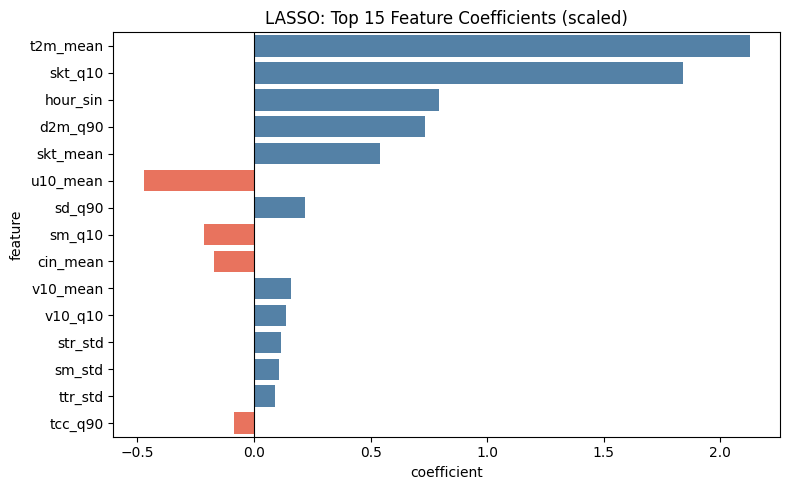

In [10]:
coefs = best_linear.named_steps['reg'].coef_
coef_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'coefficient': coefs
}).sort_values('coefficient', key=abs, ascending=False)
 
print(f'\nTop 15 features by |coefficient| ({best_linear_name}):')
print(coef_df.head(15).to_string(index=False))
 
if best_linear_name == 'LASSO':
    n_zero = (coefs == 0).sum()
    print(f'\nLASSO zeroed out {n_zero}/{len(FEATURE_COLS)} features')
 
plt.figure(figsize=(8, 5))
top15 = coef_df.head(15)
colors = ['steelblue' if c > 0 else 'tomato' for c in top15['coefficient']]
sns.barplot(x='coefficient', y='feature', data=top15, palette=colors)
plt.title(f'{best_linear_name}: Top 15 Feature Coefficients (scaled)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

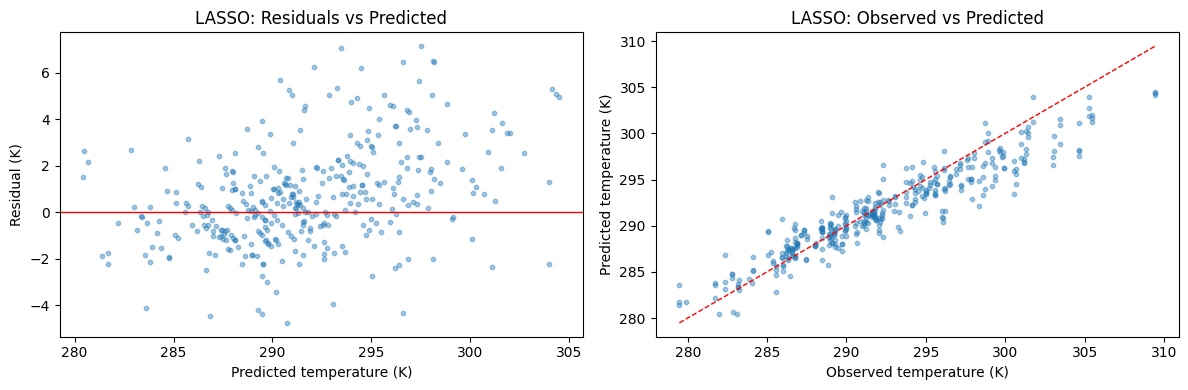

In [11]:
residuals = y_test - y_test_pred
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].scatter(y_test_pred, residuals, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Predicted temperature (K)')
axes[0].set_ylabel('Residual (K)')
axes[0].set_title(f'{best_linear_name}: Residuals vs Predicted')
 
axes[1].scatter(y_test, y_test_pred, alpha=0.4, s=10)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set_xlabel('Observed temperature (K)')
axes[1].set_ylabel('Predicted temperature (K)')
axes[1].set_title(f'{best_linear_name}: Observed vs Predicted')
 
plt.tight_layout()
plt.show()

In [12]:
import joblib
joblib.dump(best_linear, 'linear_best_model.pkl')
print(f'\nModel saved to linear_best_model.pkl ({best_linear_name})')


Model saved to linear_best_model.pkl (LASSO)


In [ ]:
import joblib, numpy as np, pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

best_linear = joblib.load('models/Linear/linear_best_model.pkl')


test = pd.read_csv('processed_data/test.csv', parse_dates=['model_time', 'valid_time'])
DROP_COLS = ['model_time', 'valid_time', 'obs_temp_C']
TARGET = 'obs_temp_K'
FEATURE_COLS = [c for c in test.columns if c not in DROP_COLS + [TARGET]]

X_test, y_test = test[FEATURE_COLS], test[TARGET]
y_pred = best_linear.predict(X_test)

print(f'Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} K')
print(f'Test MAE  : {mean_absolute_error(y_test, y_pred):.4f} K')
print(f'Test R²   : {r2_score(y_test, y_pred):.4f}')

Test RMSE : 2.1516 K
Test MAE  : 1.6142 K
Test R²   : 0.8944
